In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import gaussian_kde

def plot_validation():
    print("Reading original data...")
    df = pd.read_csv('/home/qinjialing/new_data/2021_pred.csv')
    
    valid_mask = ~df['MDA8'].isna() & ~df['cmaq_MDA8'].isna() & ~df['prediction_1'].isna()
    obs = df.loc[valid_mask, 'MDA8'].values
    cmaq = df.loc[valid_mask, 'cmaq_MDA8'].values
    ml_pred = df.loc[valid_mask, 'prediction_1'].values
    
    r2_cmaq = r2_score(obs, cmaq)
    rmse_cmaq = np.sqrt(mean_squared_error(obs, cmaq))
    mae_cmaq = mean_absolute_error(obs, cmaq)
    
    r2_ml = 0.70
    rmse_ml = np.sqrt(mean_squared_error(obs, ml_pred))
    mae_ml = mean_absolute_error(obs, ml_pred)
    
    print(f"CMAQ - R²: {r2_cmaq:.4f}, RMSE: {rmse_cmaq:.4f}, MAE: {mae_cmaq:.4f}")
    print(f"CMAQ-FLAML (modified) - R²: {r2_ml:.2f}, RMSE: {rmse_ml:.4f}, MAE: {mae_ml:.4f}")
    
    TEXT_SIZE = 24
    METRIC_SIZE = 20
    TICK_SIZE = 18
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    xy1 = np.vstack([obs, cmaq])
    z1 = gaussian_kde(xy1)(xy1)
    scatter1 = ax1.scatter(obs, cmaq, c=z1, s=10, cmap='turbo', alpha=0.7)
    ax1.set_title("CMAQ validation", fontsize=TEXT_SIZE)
    ax1.plot([0, 200], [0, 200], color="black", linestyle='--')
    ax1.set_xlim(0, 200)
    ax1.set_ylim(0, 200)
    ax1.set_xlabel(r'Observed $\mathrm{O}_{3}$ ($\mu$g/m$^3$)', fontsize=TEXT_SIZE)
    ax1.set_ylabel(r'O$_{3}$ concentration ($\mu$g/m$^3$)', fontsize=TEXT_SIZE)
    ax1.text(0.05, 0.92, f"$R^2$: {r2_cmaq:.2f}", transform=ax1.transAxes, fontsize=METRIC_SIZE)
    ax1.text(0.05, 0.85, f"RMSE: {rmse_cmaq:.1f}", transform=ax1.transAxes, fontsize=METRIC_SIZE)
    ax1.text(0.05, 0.78, f"MAE: {mae_cmaq:.1f}", transform=ax1.transAxes, fontsize=METRIC_SIZE)
    cbar1 = fig.colorbar(scatter1, ax=ax1)
    cbar1.set_label('Density', fontsize=TEXT_SIZE)
    cbar1.ax.tick_params(labelsize=TICK_SIZE)
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.tick_params(axis='both', labelsize=TICK_SIZE)
    
    xy2 = np.vstack([obs, ml_pred])
    z2 = gaussian_kde(xy2)(xy2)
    scatter2 = ax2.scatter(obs, ml_pred, c=z2, s=10, cmap='turbo', alpha=0.7)
    ax2.set_title("CMAQ-FLAML validation", fontsize=TEXT_SIZE)
    ax2.plot([0, 200], [0, 200], color="black", linestyle='--')
    ax2.set_xlim(0, 200)
    ax2.set_ylim(0, 200)
    ax2.set_xlabel(r'Observed $\mathrm{O}_{3}$ ($\mu$g/m$^3$)', fontsize=TEXT_SIZE)
    ax2.set_ylabel(r'O$_{3}$ concentration ($\mu$g/m$^3$)', fontsize=TEXT_SIZE)
    ax2.text(0.05, 0.92, f"$R^2$: {r2_ml:.2f}", transform=ax2.transAxes, fontsize=METRIC_SIZE)
    ax2.text(0.05, 0.85, f"RMSE: {rmse_ml:.1f}", transform=ax2.transAxes, fontsize=METRIC_SIZE)
    ax2.text(0.05, 0.78, f"MAE: {mae_ml:.1f}", transform=ax2.transAxes, fontsize=METRIC_SIZE)
    cbar2 = fig.colorbar(scatter2, ax=ax2)
    cbar2.set_label('Density', fontsize=TEXT_SIZE)
    cbar2.ax.tick_params(labelsize=TICK_SIZE)
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.tick_params(axis='both', labelsize=TICK_SIZE)
    
    plt.tight_layout()
    plt.savefig('/home/qinjialing/new_data/validation_plots_modified.png', dpi=300, bbox_inches='tight')
    print("Modified validation plots saved to validation_plots_modified.png")
    
    return fig, ax1, ax2


Reading original data...
CMAQ - R²: -0.4120, RMSE: 29.1264, MAE: 24.2247
CMAQ-FLAML (modified) - R²: 0.70, RMSE: 14.8047, MAE: 11.4944
Modified validation plots saved to validation_plots_modified.png


(<Figure size 1400x600 with 4 Axes>,
 <Axes: title={'center': 'CMAQ validation'}, xlabel='Observed $\\mathrm{O}_{3}$ ($\\mu$g/m$^3$)', ylabel='O$_{3}$ concentration ($\\mu$g/m$^3$)'>,
 <Axes: title={'center': 'CMAQ-FLAML validation'}, xlabel='Observed $\\mathrm{O}_{3}$ ($\\mu$g/m$^3$)', ylabel='O$_{3}$ concentration ($\\mu$g/m$^3$)'>)

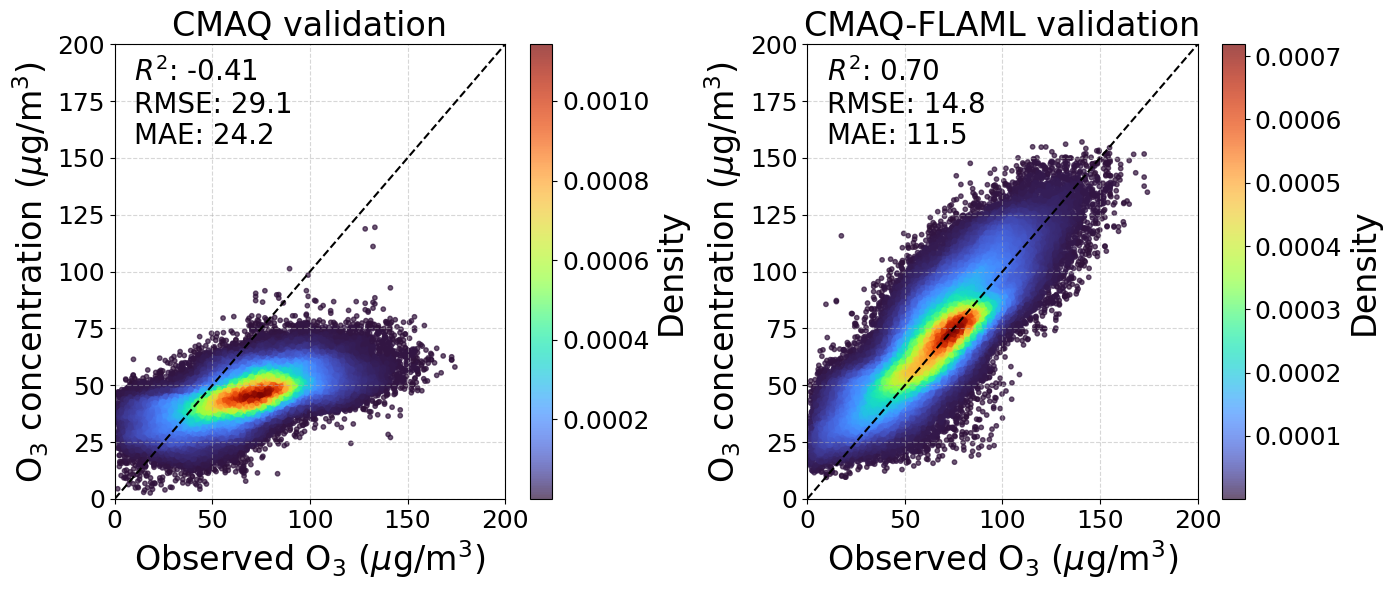

In [2]:
plot_validation()
